Install & Imports

In [1]:
!pip install pandas scikit-learn nltk transformers datasets kaggle -q
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re
import nltk
import torch
import time
from transformers import Trainer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [2]:
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

GPU available: True
GPU name: Tesla T4


Download & Load Sentiment140

In [3]:
!kaggle datasets download -d kazanova/sentiment140
!unzip -o sentiment140.zip

# Dataset has no headers → define manually
columns = ['target', 'ids', 'date', 'flag', 'user', 'text']

df = pd.read_csv(
    'training.1600000.processed.noemoticon.csv',
    encoding='ISO-8859-1',
    names=columns
)

df.head()

print("Shape of dataset:", df.shape)

df = df[['text', 'target']]

print(df['target'].value_counts())



Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
sentiment140.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  sentiment140.zip
  inflating: training.1600000.processed.noemoticon.csv  
Shape of dataset: (1600000, 6)
target
0    800000
4    800000
Name: count, dtype: int64


Map Labels :

0 = negative ,
4 = positive

In [4]:
label_map = {
    0: 0,   # negative
    4: 1    # positive
}
df = df[df['target'] != 2]  # remove neutral if exists (safety)

df['label'] = df['target'].map(label_map)

df = df.dropna(subset=['label'])   # 🔥 ADD THIS LINE
df['label'] = df['label'].astype(int)
df.head()


,text,target,label
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0,0
1,is upset that he can't update his Facebook by ...,0,0
2,@Kenichan I dived many times for the ball. Man...,0,0
3,my whole body feels itchy and like its on fire,0,0
4,"@nationwideclass no, it's not behaving at all....",0,0


Preprocessing

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text']].head(10)

df = df.sample(5000, random_state=42).reset_index(drop=True)

print("Dataset reduced for fair comparison:", df.shape)

X = df['clean_text']
y = df['label']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

Dataset reduced for fair comparison: (5000, 4)
Training samples: 4000
Testing samples: 1000


VADER

In [6]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def vader_predict(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0:
        return 1   # positive
    else:
        return 0   # negative

y_pred_vader = X_test_text.apply(vader_predict)

print("VADER Accuracy:", accuracy_score(y_test, y_pred_vader))
print("VADER F1:", f1_score(y_test, y_pred_vader, average='weighted'))

VADER Accuracy: 0.671
VADER F1: 0.65328340666188


Logistic Regression

In [7]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression F1:", f1_score(y_test, y_pred_lr, average='weighted'))

print("Unique labels in training set:", set(y_train))
print("Unique labels in test set:", set(y_test))

Logistic Regression Accuracy: 0.707
Logistic Regression F1: 0.7069815400954647
Unique labels in training set: {0, 1}
Unique labels in test set: {0, 1}


BERT Setup

In [8]:
from datasets import Dataset
from transformers import BertTokenizer, BertForSequenceClassification

train_df = pd.DataFrame({'text': X_train_text, 'label': y_train})
test_df = pd.DataFrame({'text': X_test_text, 'label': y_test})

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize(example):
    return tokenizer(example['text'], truncation=True, padding='max_length', max_length=128)

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2   # 🔥 IMPORTANT CHANGE
)

print("BERT ready")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT ready


BERT Training

In [9]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    logging_dir='./logs',
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()

predictions = trainer.predict(test_dataset)

y_pred_bert = predictions.predictions.argmax(axis=1)
y_true_bert = y_test.values

print("BERT Accuracy:", accuracy_score(y_true_bert, y_pred_bert))
print("BERT F1:", f1_score(y_true_bert, y_pred_bert, average='weighted'))

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Step,Training Loss
500,0.533676
1000,0.317404


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT Accuracy: 0.796
BERT F1: 0.7959412329556367


In [12]:
print(classification_report(y_true_bert, y_pred_bert))

              precision    recall  f1-score   support

           0       0.79      0.81      0.80       499
           1       0.81      0.78      0.79       501

    accuracy                           0.80      1000
   macro avg       0.80      0.80      0.80      1000
weighted avg       0.80      0.80      0.80      1000



Final Results + Visualisation

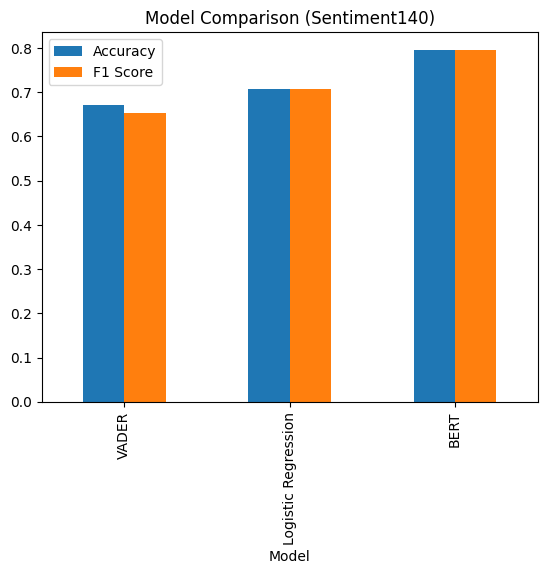

In [10]:
final_results = pd.DataFrame({
    'Model': ['VADER', 'Logistic Regression', 'BERT'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_vader),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_true_bert, y_pred_bert)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_vader, average='weighted'),
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_true_bert, y_pred_bert, average='weighted')
    ]
})

final_results.set_index('Model').plot(kind='bar')
plt.title("Model Comparison (Sentiment140)")
plt.show()

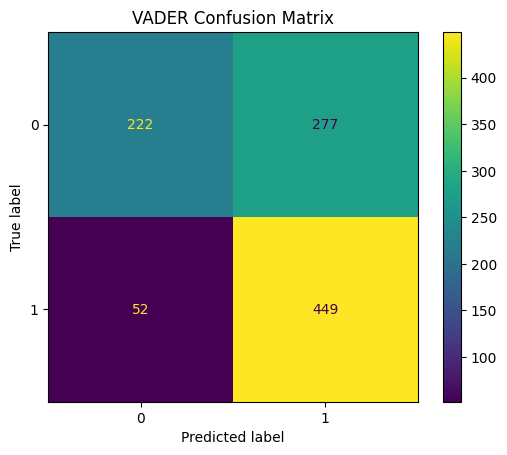

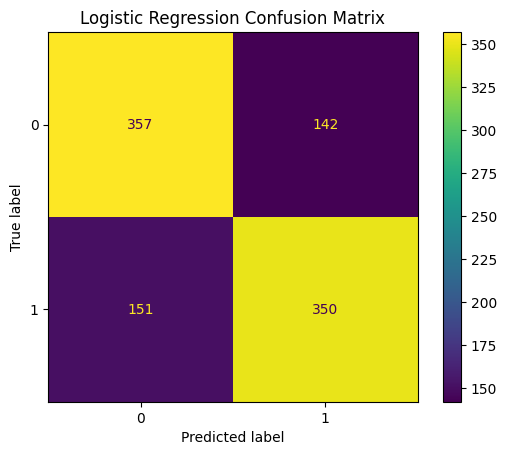

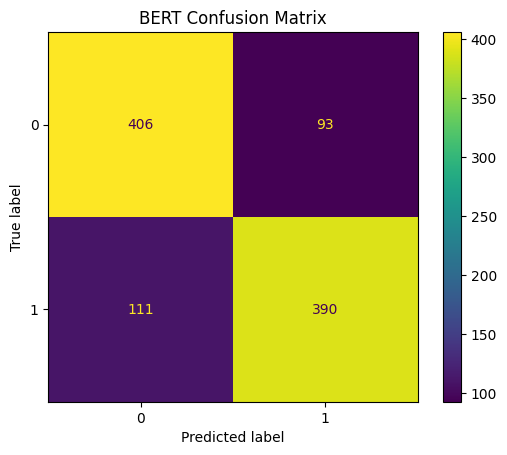

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

# VADER
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_vader)
plt.title("VADER Confusion Matrix")
plt.show()

# Logistic
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# BERT
ConfusionMatrixDisplay.from_predictions(y_true_bert, y_pred_bert)
plt.title("BERT Confusion Matrix")
plt.show()